In [1]:
import numpy as np
import pandas as pd
import os
import random
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

from PIL import Image
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 30
LR = 1e-3
print(f'Device: {DEVICE}')

Device: cuda


label
benign       437
malignant    210
normal       133
Name: count, dtype: int64
Total samples: 780


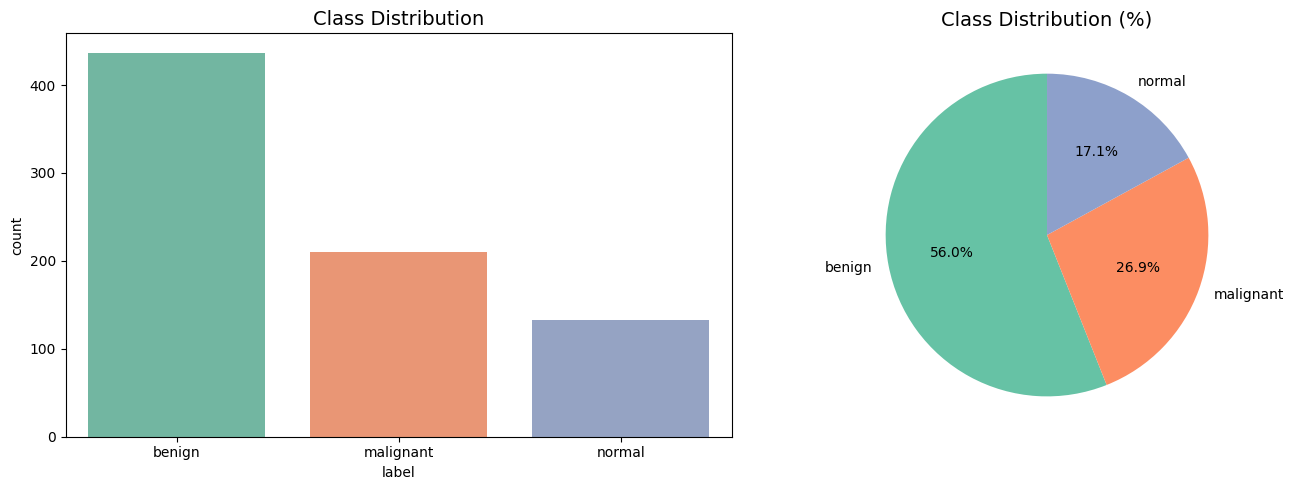

In [2]:
dataset_path = "/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
classes = ["benign", "malignant", "normal"]
data = []
for label in classes:
    class_path = os.path.join(dataset_path, label)
    for file in sorted(os.listdir(class_path)):
        if file.endswith(".png") and "_mask" not in file:
            image_path = os.path.join(class_path, file)
            mask_path = os.path.join(class_path, file.replace(".png", "_mask.png"))
            if os.path.exists(mask_path):
                data.append({"image_path": image_path, "mask_path": mask_path, "label": label})

df = pd.DataFrame(data)
print(df['label'].value_counts())
print(f'Total samples: {len(df)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='label', ax=axes[0], palette='Set2')
axes[0].set_title('Class Distribution', fontsize=14)
class_counts = df['label'].value_counts()
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
axes[1].set_title('Class Distribution (%)', fontsize=14)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

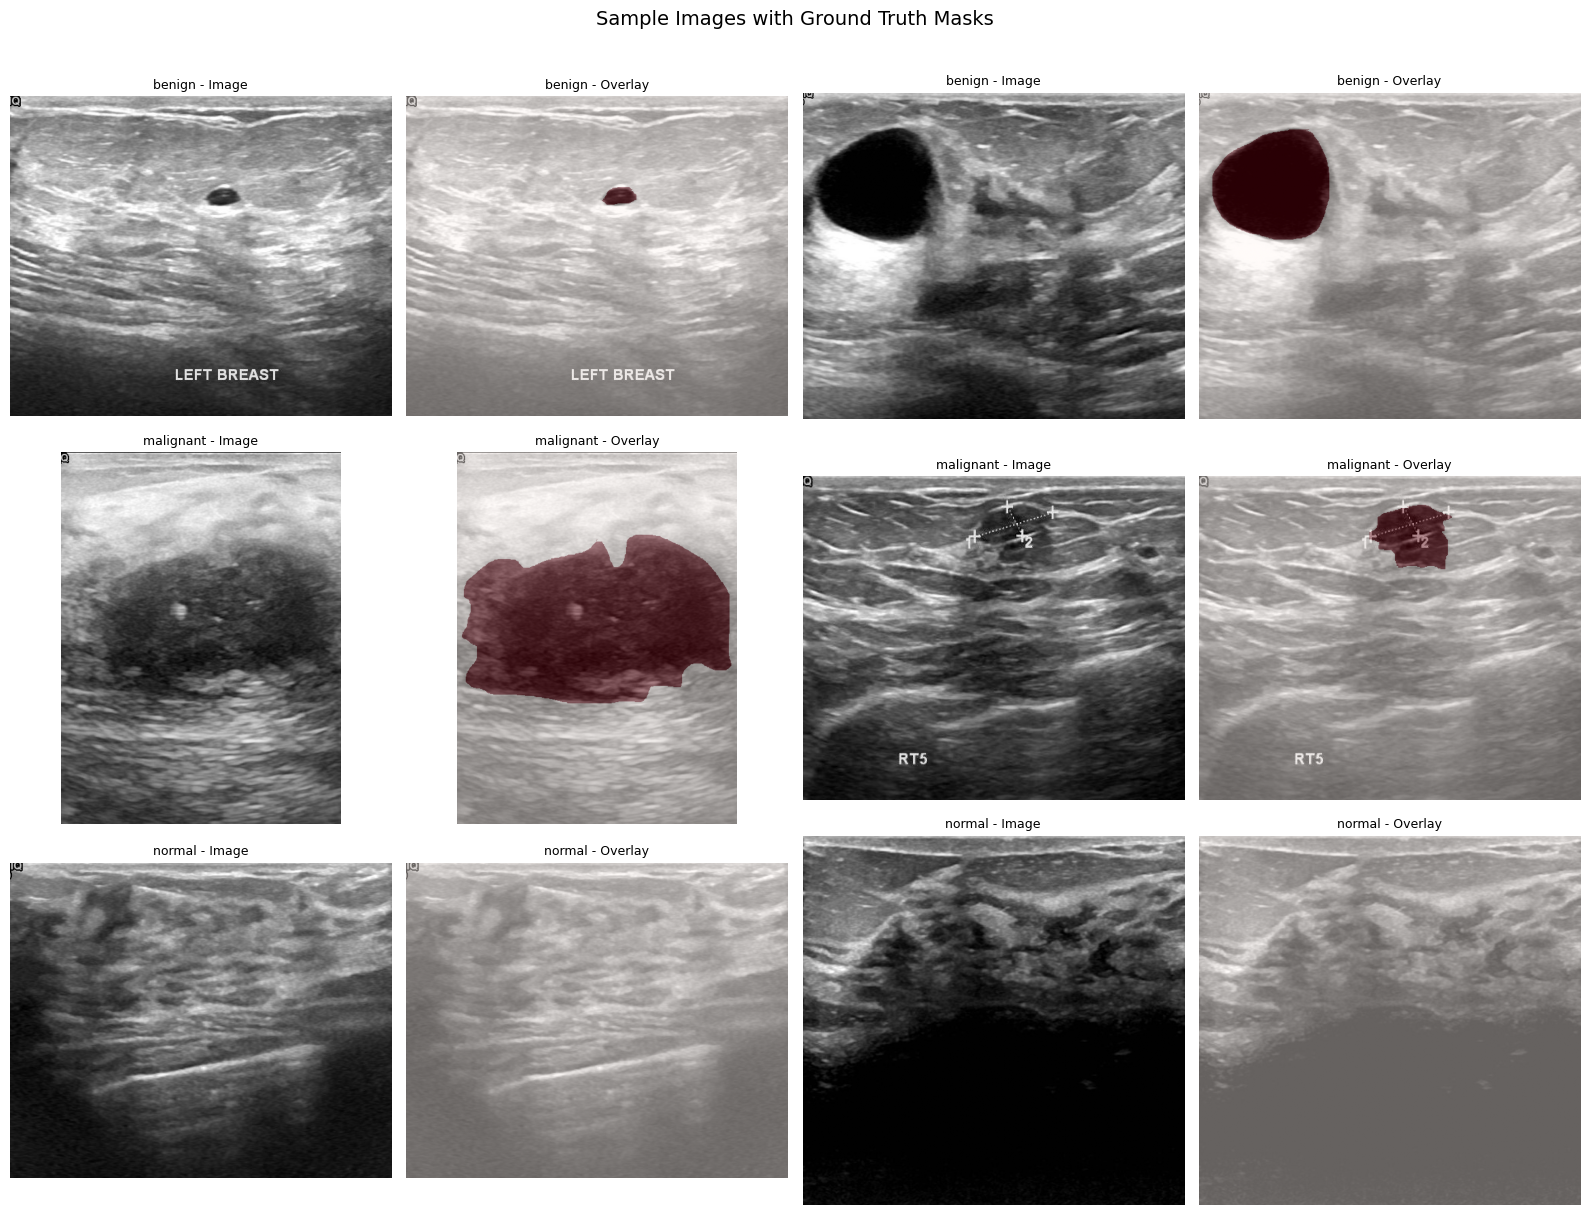

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, label in enumerate(classes):
    subset = df[df['label'] == label].iloc[:4]
    for j, (_, row) in enumerate(subset.iterrows()):
        if j < 2:
            img = np.array(Image.open(row['image_path']).convert('L'))
            mask = np.array(Image.open(row['mask_path']).convert('L'))
            ax = axes[i][j*2]
            ax.imshow(img, cmap='gray')
            ax.set_title(f'{label} - Image', fontsize=9)
            ax.axis('off')
            ax2 = axes[i][j*2+1]
            ax2.imshow(img, cmap='gray')
            ax2.imshow(mask, alpha=0.4, cmap='Reds')
            ax2.set_title(f'{label} - Overlay', fontsize=9)
            ax2.axis('off')
plt.suptitle('Sample Images with Ground Truth Masks', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])
print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')

class BUSIDataset(Dataset):
    def __init__(self, df, img_size=256, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        mask = Image.open(row['mask_path']).convert('L')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        if self.augment:
            if random.random() > 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                img = TF.vflip(img)
                mask = TF.vflip(mask)
            angle = random.uniform(-30, 30)
            img = TF.rotate(img, angle)
            mask = TF.rotate(mask, angle)
            if random.random() > 0.5:
                img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))
                img = TF.adjust_contrast(img, random.uniform(0.8, 1.2))
        img = TF.to_tensor(img)
        img = TF.normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask = torch.from_numpy(np.array(mask)).float() / 255.0
        mask = (mask > 0.5).float().unsqueeze(0)
        label = {'benign': 0, 'malignant': 1, 'normal': 2}[row['label']]
        return img, mask, label, row['label']

train_ds = BUSIDataset(train_df, IMG_SIZE, augment=True)
val_ds = BUSIDataset(val_df, IMG_SIZE, augment=False)
test_ds = BUSIDataset(test_df, IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print('DataLoaders ready.')

Train: 624, Val: 78, Test: 78
DataLoaders ready.


Stage 1: Training mask generator + classifier (UNet)


Train:   0%|          | 0/78 [00:00<?, ?it/s]

Val:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 | 39.4s | train_loss=2.3559 val_loss=2.6657 | train_dice=0.1136 val_dice=0.1795 | train_iou=0.1085 val_iou=0.1795 | train_acc=0.5304 val_acc=0.5513


Train:   0%|          | 0/78 [00:00<?, ?it/s]

...

Val:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 9/10 | 26.6s | train_loss=1.7974 val_loss=1.7851 | train_dice=0.3880 val_dice=0.4116 | train_iou=0.2895 val_iou=0.3190 | train_acc=0.6202 val_acc=0.6410


Train:   0%|          | 0/78 [00:00<?, ?it/s]

Val:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 10/10 | 26.2s | train_loss=1.7634 val_loss=1.7606 | train_dice=0.3973 val_dice=0.4045 | train_iou=0.2989 val_iou=0.3104 | train_acc=0.6266 val_acc=0.6667


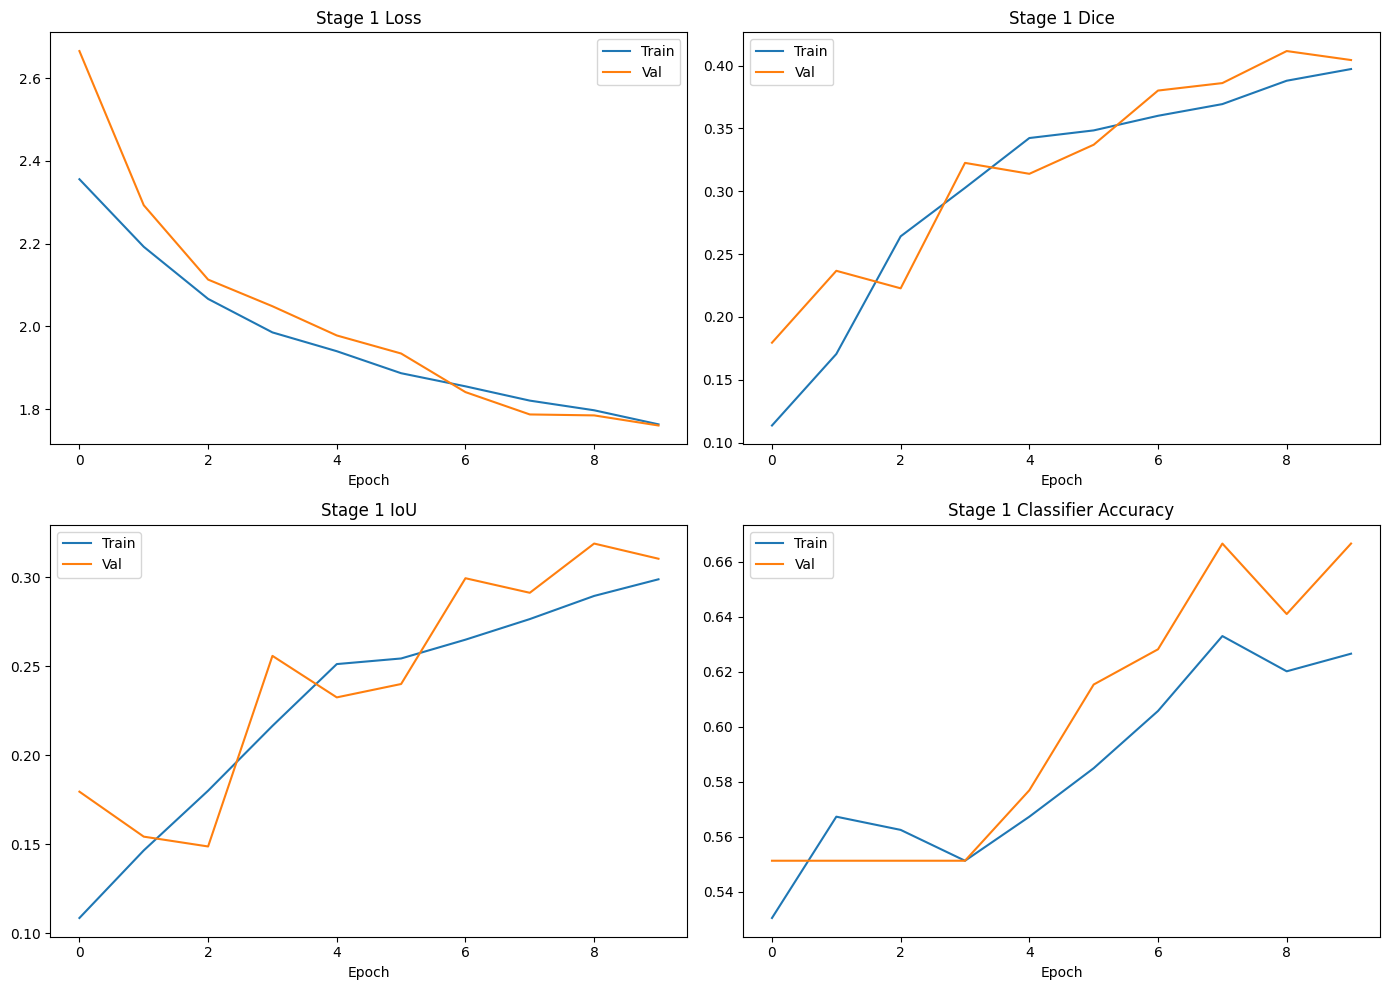

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 182MB/s]


Stage 2: Training ViT-P point classifier


Train:   0%|          | 0/78 [00:00<?, ?it/s]

Val:   0%|          | 0/10 [00:00<?, ?it/s]

...

Val:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 9/10 | 43.3s | train_loss=0.0726 val_loss=0.2133 | train_acc=0.9808 val_acc=0.9359


Train:   0%|          | 0/78 [00:00<?, ?it/s]

Val:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 10/10 | 43.4s | train_loss=0.0685 val_loss=0.2781 | train_acc=0.9808 val_acc=0.9359


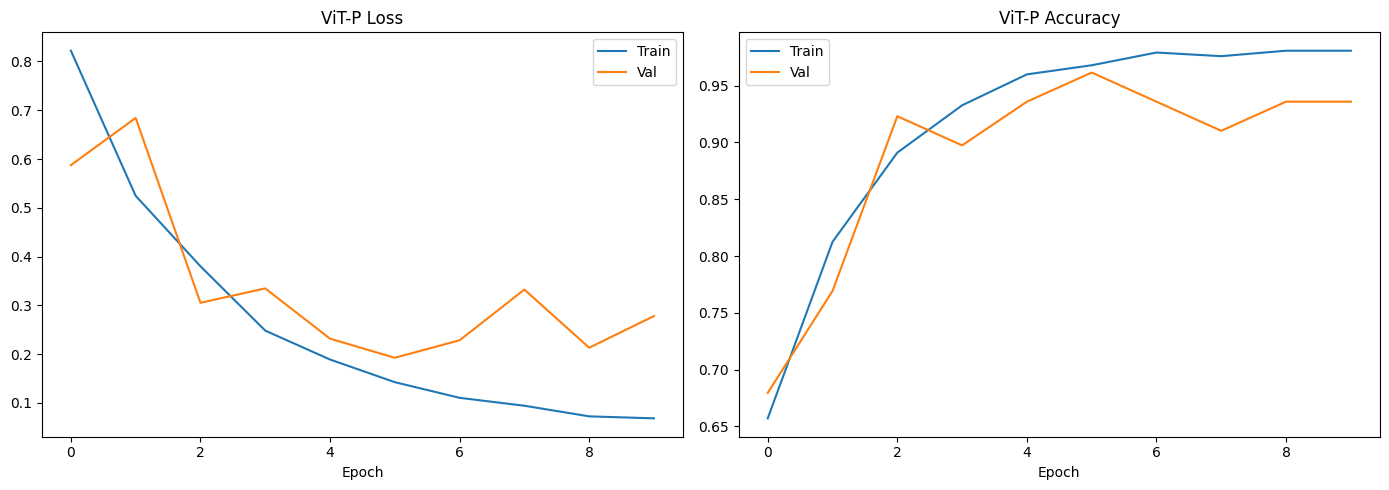

Fusing predictions:   0%|          | 0/78 [00:00<?, ?it/s]


Test Segmentation | Dice: 0.4679 | IoU: 0.3689

Mask Classifier (Cm) Accuracy:  0.7179
Point Classifier (Cp/ViT-P) Accuracy: 0.9231
Fused Classifier Accuracy: 0.8974

Classification Report (Fused):
              precision    recall  f1-score   support

      benign     0.8913    0.9318    0.9111        44
   malignant     1.0000    0.8095    0.8947        21
      normal     0.8000    0.9231    0.8571        13

    accuracy                         0.8974        78
   macro avg     0.8971    0.8881    0.8877        78
weighted avg     0.9054    0.8974    0.8977        78



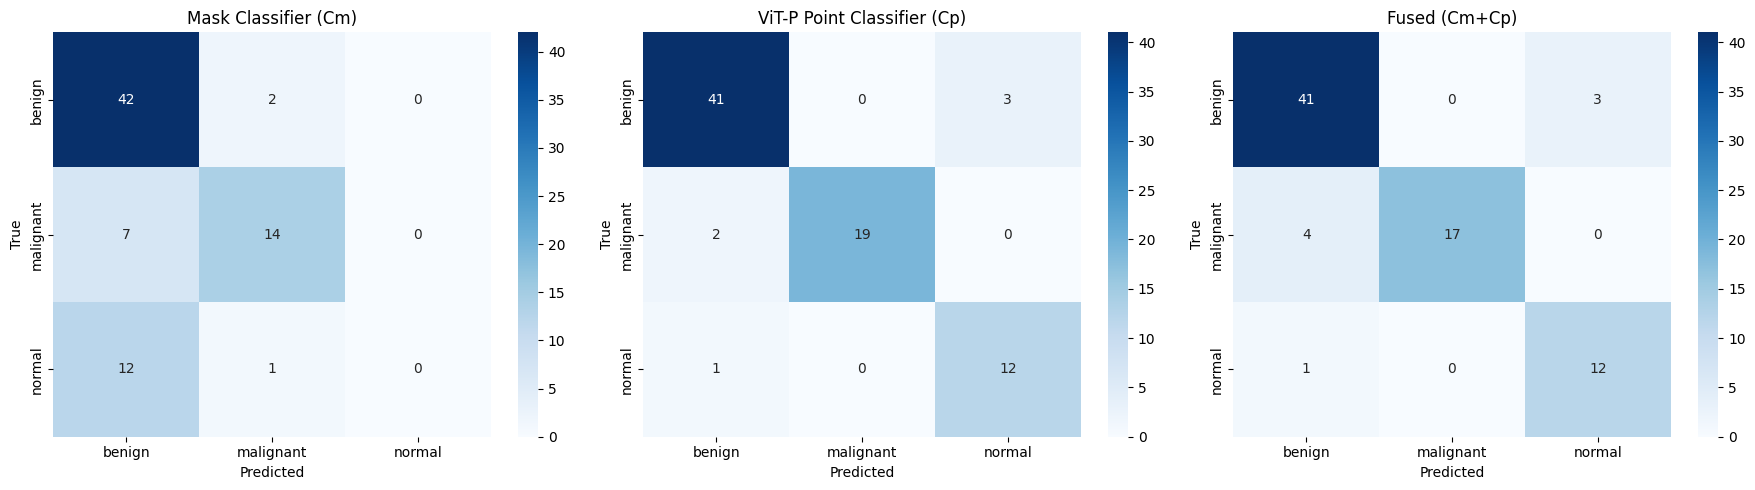

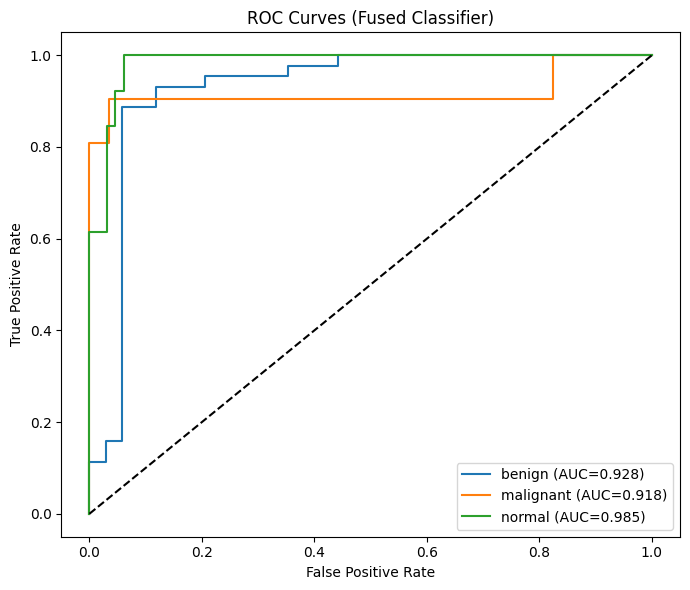

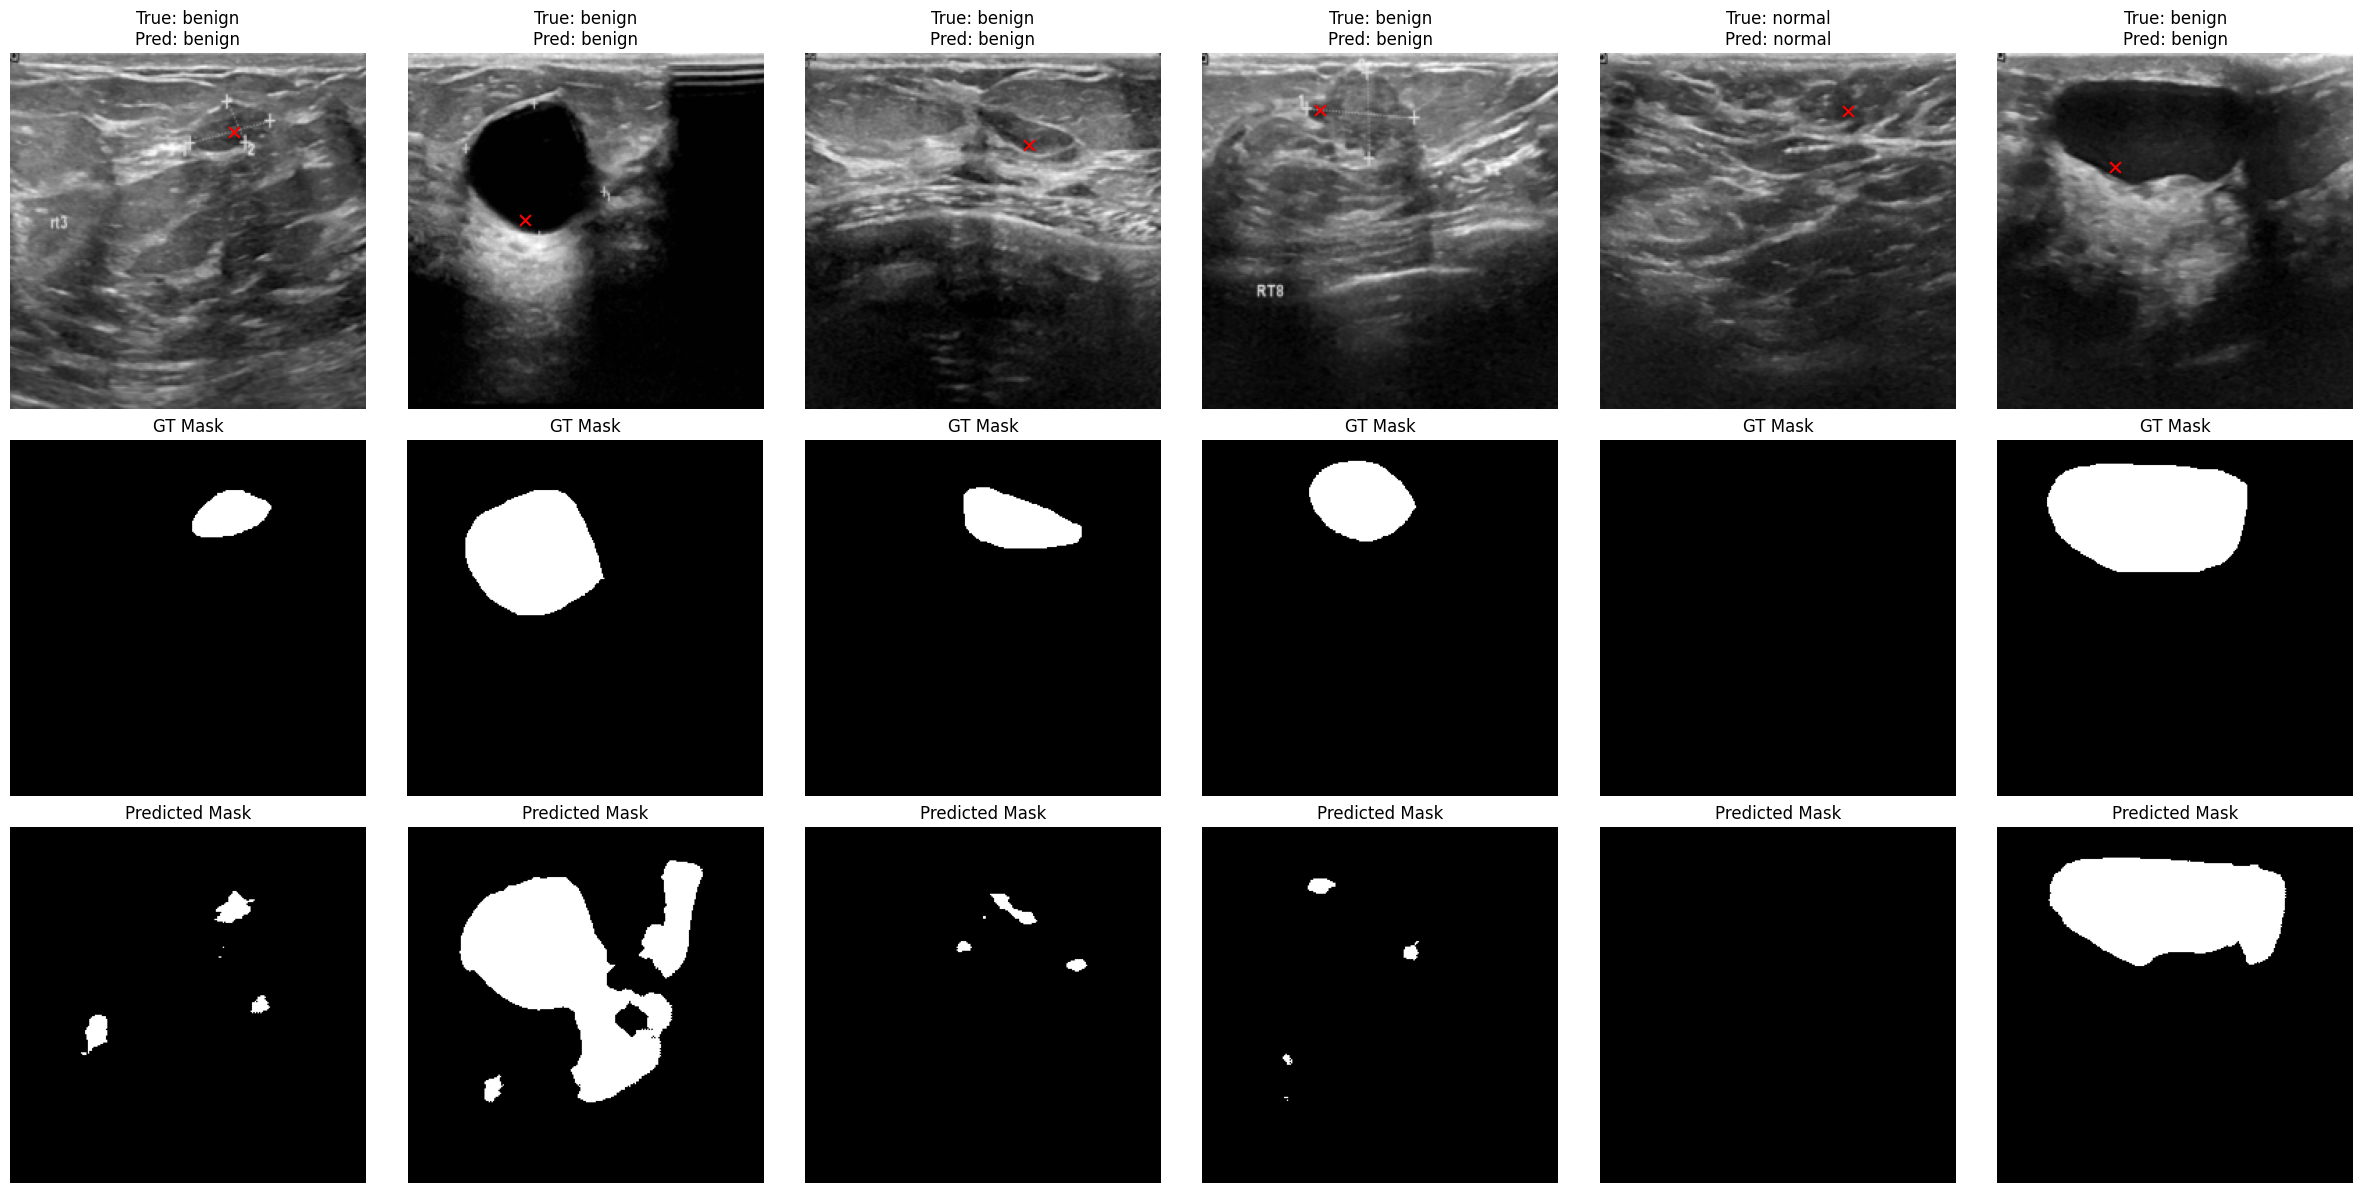

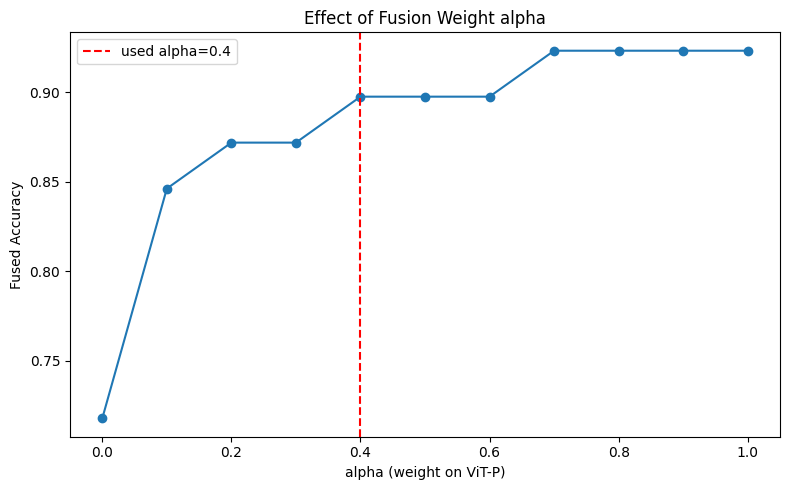


Final Summary
Mask Generator (Dice): 0.4679
Mask Generator (IoU): 0.3689
Cm Accuracy: 0.7179
Cp (ViT-P) Accuracy: 0.9231
Fused Accuracy: 0.8974


In [5]:
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.models import vit_b_16, ViT_B_16_Weights
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 10
LR = 1e-3
SEED = 42
CLASS_NAMES = ['benign', 'malignant', 'normal']
LABEL2IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])

class BUSIDataset(Dataset):
    def __init__(self, df, img_size=256, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        mask = Image.open(row['mask_path']).convert('L')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        if self.augment:
            if random.random() > 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                img = TF.vflip(img)
                mask = TF.vflip(mask)
            angle = random.uniform(-30, 30)
            img = TF.rotate(img, angle)
            mask = TF.rotate(mask, angle)
            if random.random() > 0.5:
                img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))
                img = TF.adjust_contrast(img, random.uniform(0.8, 1.2))
        img = TF.to_tensor(img)
        img = TF.normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask = torch.from_numpy(np.array(mask)).float() / 255.0
        mask = (mask > 0.5).float().unsqueeze(0)
        label = LABEL2IDX[row['label']]
        return img, mask, label, row['label']

train_ds = BUSIDataset(train_df, IMG_SIZE, augment=True)
val_ds = BUSIDataset(val_df, IMG_SIZE, augment=False)
test_ds = BUSIDataset(test_df, IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNetClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.enc1 = ConvBlock(3, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.enc4 = ConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(256, 512)
        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = ConvBlock(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = ConvBlock(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = ConvBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = ConvBlock(64, 32)
        self.mask_head = nn.Conv2d(32, 1, 1)
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        mask_logits = self.mask_head(d1)
        cls_logits = self.cls_head(b)
        return mask_logits, cls_logits

def dice_coeff(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (union + eps)).mean().item()

def iou_score(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum(dim=(1, 2, 3))
    union = ((pred + target) >= 1).float().sum(dim=(1, 2, 3))
    return ((inter + eps) / (union + eps)).mean().item()

def dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)
    inter = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return 1 - ((2 * inter + eps) / (union + eps)).mean()

stage1_model = UNetClassifier(num_classes=3).to(DEVICE)
bce_loss_fn = nn.BCEWithLogitsLoss()
ce_loss_fn = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(stage1_model.parameters(), lr=LR)
scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer1, T_max=EPOCHS)

history1 = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': [],
            'train_iou': [], 'val_iou': [], 'train_acc': [], 'val_acc': []}

def run_epoch_stage1(loader, train=True):
    stage1_model.train() if train else stage1_model.eval()
    total_loss, total_dice, total_iou, correct, total = 0.0, 0.0, 0.0, 0, 0
    pbar = tqdm(loader, desc='Train' if train else 'Val', leave=False)
    with torch.set_grad_enabled(train):
        for imgs, masks, labels, _ in pbar:
            imgs, masks, labels = imgs.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer1.zero_grad()
            mask_logits, cls_logits = stage1_model(imgs)
            loss_seg = bce_loss_fn(mask_logits, masks) + dice_loss(mask_logits, masks)
            loss_cls = ce_loss_fn(cls_logits, labels)
            loss = loss_seg + loss_cls
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(stage1_model.parameters(), 1.0)
                optimizer1.step()
            total_loss += loss.item() * imgs.size(0)
            total_dice += dice_coeff(mask_logits, masks) * imgs.size(0)
            total_iou += iou_score(mask_logits, masks) * imgs.size(0)
            preds = cls_logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
            pbar.set_postfix(loss=loss.item())
    n = len(loader.dataset)
    pbar.close()
    return total_loss / n, total_dice / n, total_iou / n, correct / total

print('Stage 1: Training mask generator + classifier (UNet)')
for epoch in range(EPOCHS):
    t0 = time.time()
    tr_loss, tr_dice, tr_iou, tr_acc = run_epoch_stage1(train_loader, train=True)
    val_loss, val_dice, val_iou, val_acc = run_epoch_stage1(val_loader, train=False)
    scheduler1.step()
    history1['train_loss'].append(tr_loss); history1['val_loss'].append(val_loss)
    history1['train_dice'].append(tr_dice); history1['val_dice'].append(val_dice)
    history1['train_iou'].append(tr_iou); history1['val_iou'].append(val_iou)
    history1['train_acc'].append(tr_acc); history1['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | {time.time()-t0:.1f}s | "
          f"train_loss={tr_loss:.4f} val_loss={val_loss:.4f} | "
          f"train_dice={tr_dice:.4f} val_dice={val_dice:.4f} | "
          f"train_iou={tr_iou:.4f} val_iou={val_iou:.4f} | "
          f"train_acc={tr_acc:.4f} val_acc={val_acc:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(history1['train_loss'], label='Train'); axes[0,0].plot(history1['val_loss'], label='Val')
axes[0,0].set_title('Stage 1 Loss'); axes[0,0].set_xlabel('Epoch'); axes[0,0].legend()
axes[0,1].plot(history1['train_dice'], label='Train'); axes[0,1].plot(history1['val_dice'], label='Val')
axes[0,1].set_title('Stage 1 Dice'); axes[0,1].set_xlabel('Epoch'); axes[0,1].legend()
axes[1,0].plot(history1['train_iou'], label='Train'); axes[1,0].plot(history1['val_iou'], label='Val')
axes[1,0].set_title('Stage 1 IoU'); axes[1,0].set_xlabel('Epoch'); axes[1,0].legend()
axes[1,1].plot(history1['train_acc'], label='Train'); axes[1,1].plot(history1['val_acc'], label='Val')
axes[1,1].set_title('Stage 1 Classifier Accuracy'); axes[1,1].set_xlabel('Epoch'); axes[1,1].legend()
plt.tight_layout(); plt.savefig('stage1_curves.png', dpi=150, bbox_inches='tight'); plt.show()

def get_highest_point(mask_logits):
    prob = torch.sigmoid(mask_logits)
    B, _, H, W = prob.shape
    flat = prob.view(B, -1)
    idx = flat.argmax(dim=1)
    ys = (idx // W).float() / (H - 1)
    xs = (idx % W).float() / (W - 1)
    return torch.stack([xs, ys], dim=1)

VITP_IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class ViTPDataset(Dataset):
    def __init__(self, df, mode='train'):
        self.df = df.reset_index(drop=True)
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB').resize((VITP_IMG_SIZE, VITP_IMG_SIZE), Image.BILINEAR)
        mask = Image.open(row['mask_path']).convert('L').resize((VITP_IMG_SIZE, VITP_IMG_SIZE), Image.NEAREST)
        mask_np = np.array(mask)
        label = LABEL2IDX[row['label']]

        if self.mode == 'train':
            ys, xs = np.where(mask_np > 127)
            if len(xs) > 0:
                i = np.random.randint(len(xs))
                px, py = xs[i], ys[i]
            else:
                px, py = np.random.randint(0, VITP_IMG_SIZE), np.random.randint(0, VITP_IMG_SIZE)
            if np.random.random() > 0.5:
                img = TF.hflip(img)
                px = VITP_IMG_SIZE - 1 - px
            point = torch.tensor([px / (VITP_IMG_SIZE - 1), py / (VITP_IMG_SIZE - 1)], dtype=torch.float32)
        else:
            point = torch.tensor([0.5, 0.5], dtype=torch.float32)

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, mean=IMAGENET_MEAN, std=IMAGENET_STD)
        return img_t, point, label, row['label']

class ViTP(nn.Module):
    def __init__(self, num_classes=3, freeze_layers=8):
        super().__init__()
        backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        self.hidden_dim = backbone.hidden_dim
        self.conv_proj = backbone.conv_proj
        self.pos_embedding = backbone.encoder.pos_embedding
        self.dropout = backbone.encoder.dropout
        self.layers = backbone.encoder.layers
        self.ln = backbone.encoder.ln
        self.point_embed = nn.Linear(2, self.hidden_dim)
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(self.hidden_dim), nn.Linear(self.hidden_dim, 256),
            nn.GELU(), nn.Dropout(0.3), nn.Linear(256, num_classes)
        )
        for p in self.conv_proj.parameters():
            p.requires_grad = False
        for i, layer in enumerate(self.layers):
            if i < freeze_layers:
                for p in layer.parameters():
                    p.requires_grad = False

    def forward(self, img, points):
        B = img.shape[0]
        x = self.conv_proj(img)
        x = x.flatten(2).transpose(1, 2)
        p = self.point_embed(points).unsqueeze(1)
        seq = torch.cat([p, x], dim=1)
        seq = seq + self.pos_embedding
        seq = self.dropout(seq)
        seq = self.layers(seq)
        seq = self.ln(seq)
        point_feat = seq[:, 0]
        return self.mlp_head(point_feat)

vitp_train_ds = ViTPDataset(train_df, mode='train')
vitp_val_ds = ViTPDataset(val_df, mode='train')
vitp_train_loader = DataLoader(vitp_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
vitp_val_loader = DataLoader(vitp_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

vitp_model = ViTP(num_classes=3, freeze_layers=8).to(DEVICE)
optimizer2 = torch.optim.AdamW([p for p in vitp_model.parameters() if p.requires_grad], lr=3e-4, weight_decay=1e-4)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=EPOCHS)

history2 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

def run_epoch_stage2(loader, train=True):
    vitp_model.train() if train else vitp_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='Train' if train else 'Val', leave=False)
    with torch.set_grad_enabled(train):
        for imgs, points, labels, _ in pbar:
            imgs, points, labels = imgs.to(DEVICE), points.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer2.zero_grad()
            logits = vitp_model(imgs, points)
            loss = ce_loss_fn(logits, labels)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(vitp_model.parameters(), 1.0)
                optimizer2.step()
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
            pbar.set_postfix(loss=loss.item())
    n = len(loader.dataset)
    pbar.close()
    return total_loss / n, correct / total

print('Stage 2: Training ViT-P point classifier')
for epoch in range(EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch_stage2(vitp_train_loader, train=True)
    val_loss, val_acc = run_epoch_stage2(vitp_val_loader, train=False)
    scheduler2.step()
    history2['train_loss'].append(tr_loss); history2['val_loss'].append(val_loss)
    history2['train_acc'].append(tr_acc); history2['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | {time.time()-t0:.1f}s | "
          f"train_loss={tr_loss:.4f} val_loss={val_loss:.4f} | "
          f"train_acc={tr_acc:.4f} val_acc={val_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history2['train_loss'], label='Train'); axes[0].plot(history2['val_loss'], label='Val')
axes[0].set_title('ViT-P Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history2['train_acc'], label='Train'); axes[1].plot(history2['val_acc'], label='Val')
axes[1].set_title('ViT-P Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.savefig('stage2_curves.png', dpi=150, bbox_inches='tight'); plt.show()

ALPHA = 0.4
vitp_test_ds = ViTPDataset(test_df, mode='eval')

stage1_model.eval()
vitp_model.eval()

all_true, all_cm_pred, all_cp_pred, all_fuse_pred = [], [], [], []
all_cm_prob, all_cp_prob, all_fuse_prob = [], [], []
test_dice_list, test_iou_list = [], []
viz_samples = []

with torch.no_grad():
    for i in tqdm(range(len(test_df)), desc='Fusing predictions'):
        row = test_df.iloc[i]
        img256, mask256, label_idx, label_str = test_ds[i]
        img256_b = img256.unsqueeze(0).to(DEVICE)
        mask256_b = mask256.unsqueeze(0).to(DEVICE)
        mask_logits, cls_logits = stage1_model(img256_b)
        test_dice_list.append(dice_coeff(mask_logits, mask256_b))
        test_iou_list.append(iou_score(mask_logits, mask256_b))
        cm_prob = F.softmax(cls_logits, dim=1)[0].cpu().numpy()

        img224 = Image.open(row['image_path']).convert('RGB').resize((VITP_IMG_SIZE, VITP_IMG_SIZE), Image.BILINEAR)
        img224_t = TF.normalize(TF.to_tensor(img224), mean=IMAGENET_MEAN, std=IMAGENET_STD).unsqueeze(0).to(DEVICE)
        mask_logits_224, _ = stage1_model(img224_t)
        point = get_highest_point(mask_logits_224).to(DEVICE)
        cp_logits = vitp_model(img224_t, point)
        cp_prob = F.softmax(cp_logits, dim=1)[0].cpu().numpy()

        fuse_prob = (cm_prob ** (1 - ALPHA)) * (cp_prob ** ALPHA)
        fuse_prob = fuse_prob / fuse_prob.sum()

        all_true.append(label_idx)
        all_cm_pred.append(int(np.argmax(cm_prob)))
        all_cp_pred.append(int(np.argmax(cp_prob)))
        all_fuse_pred.append(int(np.argmax(fuse_prob)))
        all_cm_prob.append(cm_prob)
        all_cp_prob.append(cp_prob)
        all_fuse_prob.append(fuse_prob)

        if len(viz_samples) < 6:
            viz_samples.append({
                'image': np.array(img224), 'gt_mask': mask256.squeeze().numpy(),
                'pred_mask': (torch.sigmoid(mask_logits)[0, 0].cpu().numpy() > 0.5),
                'point': point[0].cpu().numpy(), 'true': label_str,
                'pred': CLASS_NAMES[int(np.argmax(fuse_prob))]
            })

all_true = np.array(all_true)
all_cm_pred = np.array(all_cm_pred)
all_cp_pred = np.array(all_cp_pred)
all_fuse_pred = np.array(all_fuse_pred)
all_cm_prob = np.array(all_cm_prob)
all_cp_prob = np.array(all_cp_prob)
all_fuse_prob = np.array(all_fuse_prob)

print(f"\nTest Segmentation | Dice: {np.mean(test_dice_list):.4f} | IoU: {np.mean(test_iou_list):.4f}")
print(f"\nMask Classifier (Cm) Accuracy:  {(all_cm_pred == all_true).mean():.4f}")
print(f"Point Classifier (Cp/ViT-P) Accuracy: {(all_cp_pred == all_true).mean():.4f}")
print(f"Fused Classifier Accuracy: {(all_fuse_pred == all_true).mean():.4f}")

print("\nClassification Report (Fused):")
print(classification_report(all_true, all_fuse_pred, target_names=CLASS_NAMES, digits=4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, preds, title in zip(axes, [all_cm_pred, all_cp_pred, all_fuse_pred],
                            ['Mask Classifier (Cm)', 'ViT-P Point Classifier (Cp)', 'Fused (Cm+Cp)']):
    cm = confusion_matrix(all_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight'); plt.show()

y_true_bin = label_binarize(all_true, classes=[0, 1, 2])
fig, ax = plt.subplots(figsize=(7, 6))
for i, cname in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_fuse_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{cname} (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (Fused Classifier)'); ax.legend()
plt.tight_layout(); plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(3, 6, figsize=(24, 12))
for i, s in enumerate(viz_samples):
    axes[0, i].imshow(s['image']); axes[0, i].scatter([s['point'][0] * VITP_IMG_SIZE], [s['point'][1] * VITP_IMG_SIZE], c='red', s=60, marker='x')
    axes[0, i].set_title(f"True: {s['true']}\nPred: {s['pred']}"); axes[0, i].axis('off')
    axes[1, i].imshow(s['gt_mask'], cmap='gray'); axes[1, i].set_title('GT Mask'); axes[1, i].axis('off')
    axes[2, i].imshow(s['pred_mask'], cmap='gray'); axes[2, i].set_title('Predicted Mask'); axes[2, i].axis('off')
plt.tight_layout(); plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight'); plt.show()

alphas = np.linspace(0, 1, 11)
alpha_accs = []
for a in alphas:
    fp = (all_cm_prob ** (1 - a)) * (all_cp_prob ** a)
    fp = fp / fp.sum(axis=1, keepdims=True)
    pred = fp.argmax(axis=1)
    alpha_accs.append((pred == all_true).mean())

plt.figure(figsize=(8, 5))
plt.plot(alphas, alpha_accs, marker='o')
plt.axvline(ALPHA, color='red', linestyle='--', label=f'used alpha={ALPHA}')
plt.xlabel('alpha (weight on ViT-P)'); plt.ylabel('Fused Accuracy')
plt.title('Effect of Fusion Weight alpha'); plt.legend()
plt.tight_layout(); plt.savefig('alpha_ablation.png', dpi=150, bbox_inches='tight'); plt.show()

summary = {
    'Mask Generator (Dice)': np.mean(test_dice_list),
    'Mask Generator (IoU)': np.mean(test_iou_list),
    'Cm Accuracy': (all_cm_pred == all_true).mean(),
    'Cp (ViT-P) Accuracy': (all_cp_pred == all_true).mean(),
    'Fused Accuracy': (all_fuse_pred == all_true).mean(),
}
print('\nFinal Summary')
for k, v in summary.items():
    print(f'{k}: {v:.4f}')